## Feature Engineering Portion

In [21]:
!pip install xgboost

In [22]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, average_precision_score, precision_score, recall_score
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import  confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns


In [23]:
# cd "data" #Uncomment this line if already in data folder

[WinError 2] The system cannot find the file specified: 'data'
C:\Users\phyll\Documents\Phyllis-Take-Home-Project-\data


In [24]:
pwd

'C:\\Users\\phyll\\Documents\\Phyllis-Take-Home-Project-\\data'

##checking my dataset

In [25]:
data = pd.read_csv('census-bureau-cleaned.csv')
data.head(5)

,age,num persons worked for employer,weeks worked in year,label,net_capital_investments,class of worker_Not in universe,class of worker_Other,class of worker_Private,class of worker_Self-employed,major industry code_Business and repair services,...,tax filer stat_Nonfiler,tax filer stat_Single,hispanic_group_Not_Hispanic,hispanic_group_Other_Hispanic,has_wage,log1p_wage_clean,has_investments,signed_log_net_cap,veterans_benefits_binary,is_self_employed
0,73,0,0,0,0,1,0,0,0,0,...,1,0,1,0,0,0.00000,0,0.000000,0,0
1,58,1,52,0,0,0,0,0,1,0,...,0,0,1,0,0,0.00000,0,0.000000,0,0
2,48,1,52,0,0,0,0,1,0,0,...,0,0,1,0,1,7.09091,0,0.000000,0,1
3,42,6,52,0,5178,0,0,1,0,0,...,0,0,1,0,0,0.00000,1,8.552367,0,0
4,28,4,30,0,0,0,0,1,0,0,...,0,1,1,0,0,0.00000,0,0.000000,0,0


In [26]:
data.columns

Index(['age', 'num persons worked for employer', 'weeks worked in year',
       'label', 'net_capital_investments', 'class of worker_Not in universe',
       'class of worker_Other', 'class of worker_Private',
       'class of worker_Self-employed',
       'major industry code_Business and repair services',
       'major industry code_Communications',
       'major industry code_Construction', 'major industry code_Education',
       'major industry code_Entertainment',
       'major industry code_Finance insurance and real estate',
       'major industry code_Hospital services',
       'major industry code_Manufacturing-durable goods',
       'major industry code_Manufacturing-nondurable goods',
       'major industry code_Medical except hospital',
       'major industry code_Not in universe or children',
       'major industry code_Other industry',
       'major industry code_Other professional services',
       'major industry code_Personal services except private HH',
       'major 

## Split for train test

In [27]:
X = data.drop('label', axis=1)
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (98732, 99)
Shape of y_train: (98732,)
Shape of X_test: (42315, 99)
Shape of y_test: (42315,)


In [28]:
F, p = f_classif(X_train, y_train)
anova_test = pd.DataFrame({"features": X_train.columns, "F": F, "p": p}).sort_values("F", ascending=False)
anova_test.head(30)

,features,F,p
74,education_ordinal,12113.034105,0.000000e+00
95,has_investments,8891.724599,0.000000e+00
3,net_capital_investments,7201.990072,0.000000e+00
96,signed_log_net_cap,5077.301881,0.000000e+00
28,major occupation code_Executive admin and mana...,4939.144300,0.000000e+00
2,weeks worked in year,4689.919850,0.000000e+00
85,sex_Male,4038.126373,0.000000e+00
36,major occupation code_Professional specialty,3862.052585,0.000000e+00
1,num persons worked for employer,3181.749498,0.000000e+00
18,major industry code_Not in universe or children,2860.484871,0.000000e+00


In [29]:
original_numerical_and_ordinal_features = ['age',
    'weeks worked in year',
    'num persons worked for employer',
    'log1p_wage_clean',
    'signed_log_net_cap',
    'education_ordinal'
]
anova_numerical_ordinal = anova_test[anova_test['features'].isin(original_numerical_and_ordinal_features)].sort_values('F', ascending=False)
display(anova_numerical_ordinal)

,features,F,p
74,education_ordinal,12113.034105,0.000000e+00
96,signed_log_net_cap,5077.301881,0.000000e+00
2,weeks worked in year,4689.919850,0.000000e+00
1,num persons worked for employer,3181.749498,0.000000e+00
94,log1p_wage_clean,106.131105,7.104809e-25
0,age,42.363139,7.616671e-11


In [30]:
print("Class distribution check:")
display(y_train.value_counts())

Class distribution check:


label
0    90067
1     8665
Name: count, dtype: int64

## ANOVA testing, looking at F values

In [31]:
dummy_features = [f for f in anova_test['features'] if f not in original_numerical_and_ordinal_features and \
                  f not in ['has_wage', 'has_investments', 'veterans_benefits_binary', 'is_self_employed']]
anova_dummy_features = anova_test[anova_test['features'].isin(dummy_features)].sort_values('F', ascending=False)
display(anova_dummy_features.head(30))

,features,F,p
3,net_capital_investments,7201.990072,0.000000e+00
28,major occupation code_Executive admin and mana...,4939.144300,0.000000e+00
85,sex_Male,4038.126373,0.000000e+00
36,major occupation code_Professional specialty,3862.052585,0.000000e+00
18,major industry code_Not in universe or children,2860.484871,0.000000e+00
32,major occupation code_Not in universe,2860.484871,0.000000e+00
4,class of worker_Not in universe,2841.329567,0.000000e+00
70,detailed household summary in household_Househ...,2357.251760,0.000000e+00
65,detailed household and family stat_Householder,2356.330578,0.000000e+00
87,tax filer stat_Joint both under 65,2227.795446,0.000000e+00


C:\Users\phyll\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\phyll\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\phyll\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


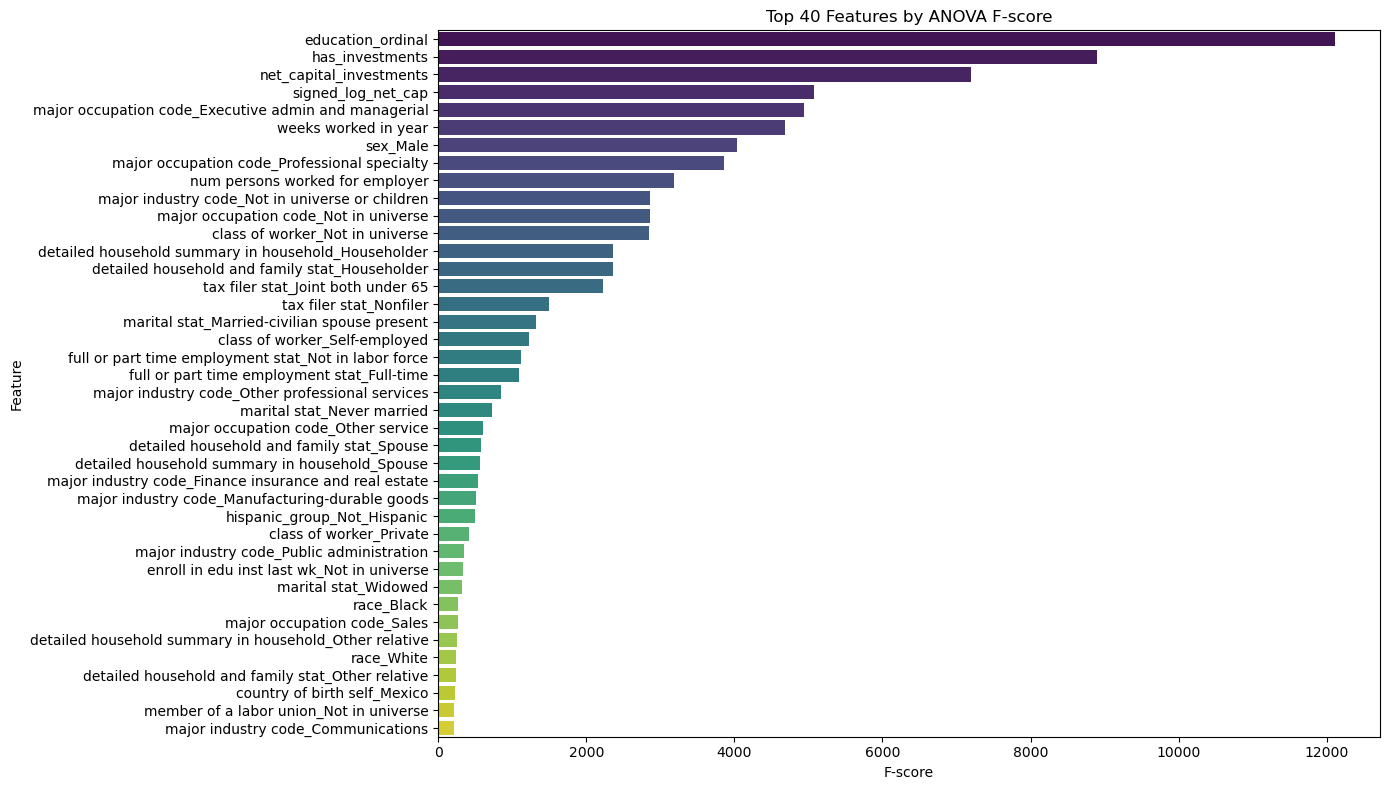

In [32]:
top_n = 40
top_f_scores = anova_test.head(top_n)

plt.figure(figsize=(14, 8))
sns.barplot(x='F', y='features', data=top_f_scores, palette='viridis')
plt.title(f'Top {top_n} Features by ANOVA F-score')
plt.xlabel('F-score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Corr Matrix

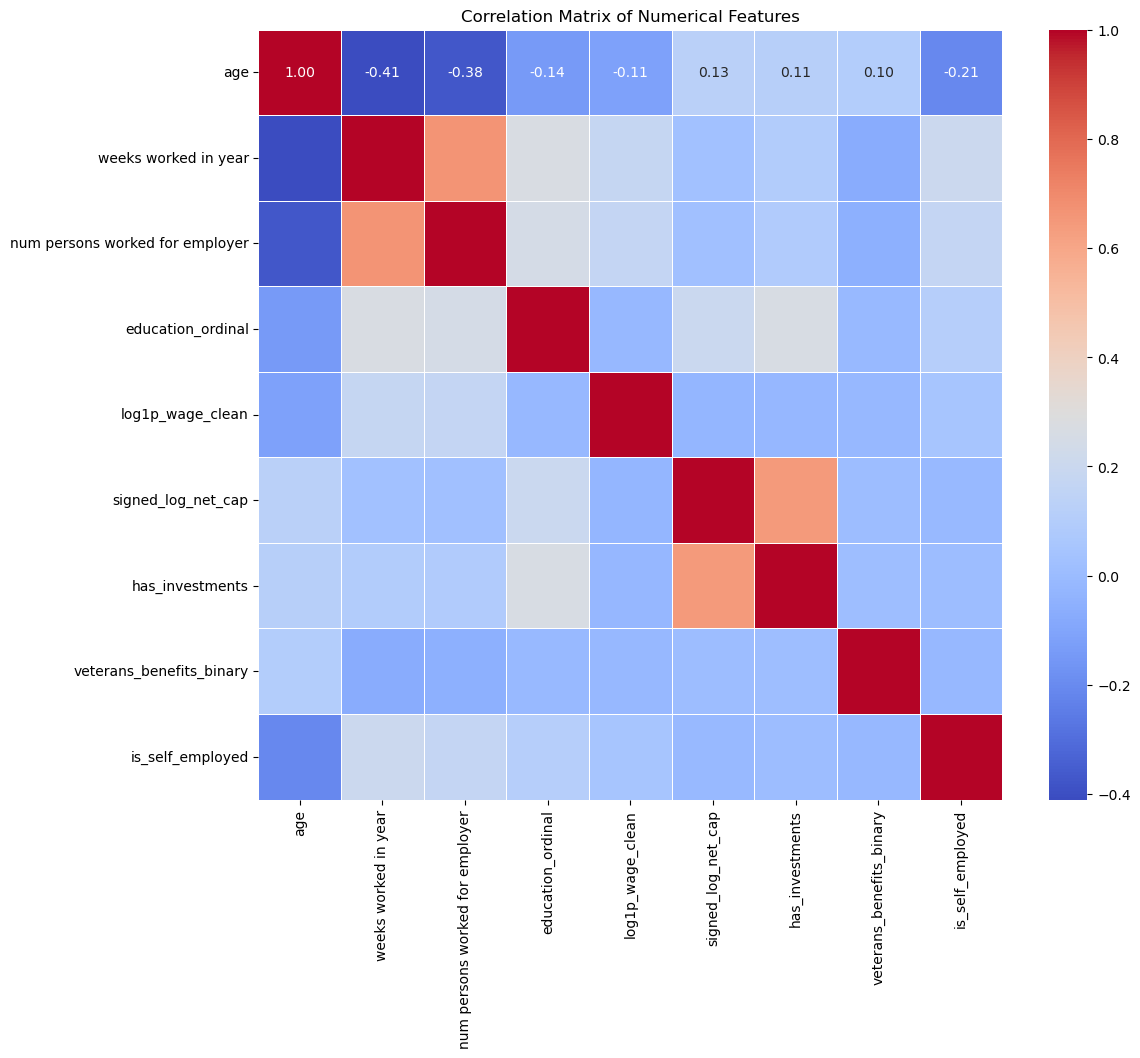

In [52]:
numerical_and_derived_features = [
    'age',
    'weeks worked in year',
    'num persons worked for employer',
    'education_ordinal',
    'log1p_wage_clean',
    'signed_log_net_cap',
    'has_investments',
    'veterans_benefits_binary',
    'is_self_employed'
]

numerical_and_derived_features = [col for col in numerical_and_derived_features if col in data.columns]

correlation_matrix = data[numerical_and_derived_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f",linewidths=0.5,  cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [34]:
features_with_low_fscore = anova_test[anova_test['F'] < 300]
display(features_with_low_fscore.tail(30))

,features,F,p
60,full or part time employment stat_Part-time,43.326947,4.654683e-11
0,age,42.363139,7.616671e-11
83,race_Other,41.598515,1.125939e-10
29,major occupation code_Farming forestry and fis...,37.049367,1.155983e-09
25,major industry code_Transportation,35.321713,2.804324e-09
33,major occupation code_Other occupation,30.837450,2.812903e-08
39,major occupation code_Technicians and related ...,26.703228,2.376852e-07
62,enroll in edu inst last wk_High school,26.315834,2.904490e-07
8,major industry code_Business and repair services,24.991642,5.767770e-07
75,marital stat_Married-A F spouse present,24.257767,8.440244e-07


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141047 entries, 0 to 141046
Data columns (total 100 columns):
 #   Column                                                       Non-Null Count   Dtype  
---  ------                                                       --------------   -----  
 0   age                                                          141047 non-null  int64  
 1   num persons worked for employer                              141047 non-null  int64  
 2   weeks worked in year                                         141047 non-null  int64  
 3   label                                                        141047 non-null  int64  
 4   net_capital_investments                                      141047 non-null  int64  
 5   class of worker_Not in universe                              141047 non-null  int64  
 6   class of worker_Other                                        141047 non-null  int64  
 7   class of worker_Private                                      141

## Dropping Features after feat enginerring

In [36]:
columns_to_drop_from_X = [
    'net_capital_investments'
]

columns_to_drop_from_X.extend([col for col in X_train.columns if col.startswith('detailed household and family stat_')])
columns_to_drop_from_X.extend([col for col in X_train.columns if col.startswith('country of birth self_')])
columns_to_drop_from_X = list(set(columns_to_drop_from_X))

X_train = X_train.drop(columns=[col for col in columns_to_drop_from_X if col in X_train.columns])
X_test = X_test.drop(columns=[col for col in columns_to_drop_from_X if col in X_test.columns])

print(f"New shape of X_train: {X_train.shape}")
print(f"New shape of X_test: {X_test.shape}")

New shape of X_train: (98732, 83)
New shape of X_test: (42315, 83)


In [37]:
X_train

,age,num persons worked for employer,weeks worked in year,class of worker_Not in universe,class of worker_Other,class of worker_Private,class of worker_Self-employed,major industry code_Business and repair services,major industry code_Communications,major industry code_Construction,...,tax filer stat_Nonfiler,tax filer stat_Single,hispanic_group_Not_Hispanic,hispanic_group_Other_Hispanic,has_wage,log1p_wage_clean,has_investments,signed_log_net_cap,veterans_benefits_binary,is_self_employed
63256,24,6,52,0,0,1,0,0,0,0,...,0,0,1,0,1,6.165418,0,0.000000,0,0
115530,39,2,52,0,0,1,0,0,0,0,...,0,0,1,0,0,0.000000,0,0.000000,0,0
43798,36,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0.000000,0,0.000000,0,0
110282,21,6,52,0,0,1,0,0,0,0,...,0,0,1,0,0,0.000000,0,0.000000,0,0
97469,45,6,52,0,0,1,0,0,0,0,...,0,1,1,0,0,0.000000,0,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18556,50,1,52,0,0,1,0,0,0,0,...,0,0,0,1,0,0.000000,0,0.000000,0,0
17679,72,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0.000000,0,0.000000,1,0
2575,29,3,30,0,0,1,0,1,0,0,...,0,0,1,0,0,0.000000,0,0.000000,0,0
69207,33,6,52,0,0,0,0,0,0,0,...,0,1,1,0,0,0.000000,0,0.000000,0,0


## RANDOM FOREST MODEL, testing versions

In [38]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.93
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96     38601
           1       0.69      0.41      0.51      3714

    accuracy                           0.93     42315
   macro avg       0.82      0.69      0.74     42315
weighted avg       0.92      0.93      0.92     42315



In [39]:
# rf_classifier = RandomForestClassifier(n_estimators=500,
#     class_weight='balanced',random_state=42)
# rf_classifier.fit(X_train, y_train)

# y_pred = rf_classifier.predict(X_test)
# print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
# print("Classification Report:\n", classification_report(y_test, y_pred))

In [40]:
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

model = XGBClassifier(eval_metric='logloss', scale_pos_weight=scale_pos_weight)
eval_set = [(X_train, y_train), (X_test, y_test)]
model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.86      0.92     38601
           1       0.37      0.81      0.50      3714

    accuracy                           0.86     42315
   macro avg       0.67      0.84      0.71     42315
weighted avg       0.93      0.86      0.88     42315

Confusion Matrix:
 [[33342  5259]
 [  688  3026]]


In [41]:
y_pred_rf = rf_classifier.predict(X_test)
y_prob_rf = rf_classifier.predict_proba(X_test)[:, 1]

pr_auc_rf = average_precision_score(y_test, y_prob_rf)
print(f"Random Forest PR-AUC, Average Precision Score: {pr_auc_rf:.4f}")

report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
precision_class_1_rf = report_rf['1']['precision']
recall_class_1_rf = report_rf['1']['recall']

print(f"Precision for label 1 ('>50k'): {precision_class_1_rf:.4f}")
print(f"Recall for label 1 ('>50k'):    {recall_class_1_rf:.4f}")

def precision_at_k(y_true, y_scores, k):
    df = pd.DataFrame({'true': y_true, 'score': y_scores})
    df = df.sort_values(by='score', ascending=False).reset_index(drop=True)

    top_k_preds = df.head(k)
    return top_k_preds['true'].sum() / k
k_val = y_test.sum()

p_at_k_rf = precision_at_k(y_test, y_prob_rf, k_val)
print(f"Precision@{k_val} for Random Forest:   {p_at_k_rf:.4f}")

Random Forest PR-AUC, Average Precision Score: 0.5966
Precision for label 1 ('>50k'): 0.6921
Recall for label 1 ('>50k'):    0.4060
Precision@3714 for Random Forest:   0.5668


## Segmentation Model, K means Clustering

In [42]:
data_for_clustering = X_train.copy()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_clustering)

In [43]:
inertia_values = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(scaled_data)
    inertia_values.append(kmeans.inertia_)

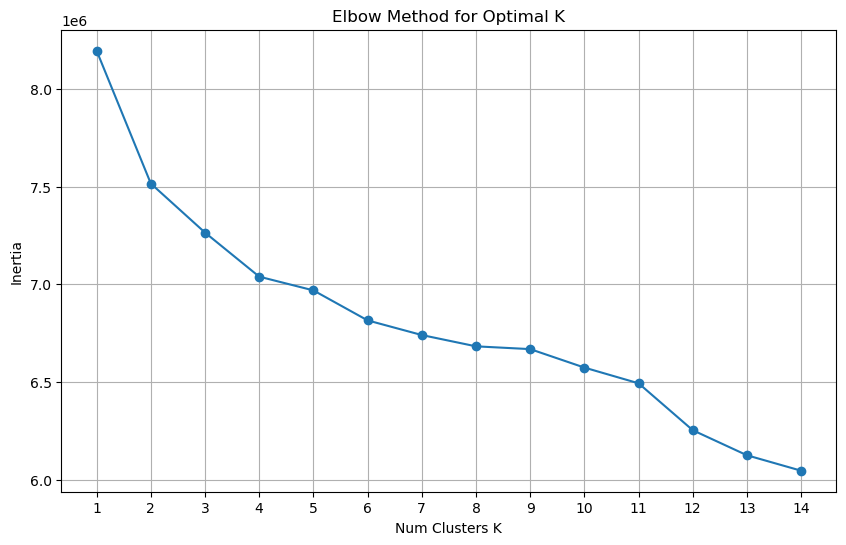

In [44]:

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Num Clusters K')
plt.ylabel('Inertia')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

In [45]:
k = 6
kmeans_model = KMeans(n_clusters=k, random_state=42, n_init='auto')
cluster_labels = kmeans_model.fit_predict(scaled_data)

X_train_clustered = X_train.copy()
X_train_clustered['Cluster'] = cluster_labels

display(X_train_clustered.head(5))

,age,num persons worked for employer,weeks worked in year,class of worker_Not in universe,class of worker_Other,class of worker_Private,class of worker_Self-employed,major industry code_Business and repair services,major industry code_Communications,major industry code_Construction,...,tax filer stat_Single,hispanic_group_Not_Hispanic,hispanic_group_Other_Hispanic,has_wage,log1p_wage_clean,has_investments,signed_log_net_cap,veterans_benefits_binary,is_self_employed,Cluster
63256,24,6,52,0,0,1,0,0,0,0,...,0,1,0,1,6.165418,0,0.0,0,0,4
115530,39,2,52,0,0,1,0,0,0,0,...,0,1,0,0,0.000000,0,0.0,0,0,2
43798,36,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0.000000,0,0.0,0,0,5
110282,21,6,52,0,0,1,0,0,0,0,...,0,1,0,0,0.000000,0,0.0,0,0,2
97469,45,6,52,0,0,1,0,0,0,0,...,1,1,0,0,0.000000,0,0.0,0,0,1


In [46]:
cluster_sizes = X_train_clustered["Cluster"].value_counts().sort_index()
print(cluster_sizes)

num_cols = ["age", "weeks worked in year","num persons worked for employer", "education_ordinal", "log1p_wage_clean", "signed_log_net_cap",
            "has_wage", "has_investments", "is_self_employed"]

cluster_numeric_profile = X_train_clustered.groupby("Cluster")[num_cols].mean()
display(cluster_numeric_profile)


Cluster
0     4161
1    20569
2    34451
3    15707
4     7386
5    16458
Name: count, dtype: int64


,age,weeks worked in year,num persons worked for employer,education_ordinal,log1p_wage_clean,signed_log_net_cap,has_wage,has_investments,is_self_employed
Cluster,,,,,,,,,
0,40.008411,46.368661,3.974045,1.366258,0.158885,0.670126,0.022831,0.175198,0.172555
1,35.266420,43.040935,3.637513,1.723613,0.000000,0.626515,0.000000,0.164957,0.212845
2,42.198427,47.087138,3.598880,1.972628,0.000000,1.311461,0.000000,0.272764,0.158921
3,58.095117,2.357739,0.388362,0.966512,0.000000,0.592348,0.000000,0.106131,0.014643
4,37.853642,46.137016,4.037233,1.495126,6.773170,0.692083,1.000000,0.163282,0.194151
5,56.120853,4.701543,0.631243,1.310791,0.000000,1.378950,0.000000,0.233807,0.017438


In [47]:
dummy_cols = [c for c in X_train_clustered.columns
              if c not in num_cols + ["Cluster"]]

global_means = X_train_clustered[dummy_cols].mean()

top_features = {}
for cl in sorted(X_train_clustered["Cluster"].unique()):
    cl_means = X_train_clustered[X_train_clustered["Cluster"] == cl][dummy_cols].mean()
    diff = (cl_means - global_means).sort_values(ascending=False)
    top_features[cl] = diff.head(15)

for cl in top_features:
    print(top_features[cl].to_frame("diff_vs_global"))


                                                    diff_vs_global
major industry code_Transportation                        0.608852
major occupation code_Transportation and materi...        0.569258
sex_Male                                                  0.311809
class of worker_Private                                   0.255908
tax filer stat_Joint both under 65                        0.152467
full or part time employment stat_Full-time               0.123738
detailed household summary in household_Househo...        0.117186
marital stat_Married-civilian spouse present              0.058617
tax filer stat_Single                                     0.032268
reason for unemployment_Job loser                         0.031228
member of a labor union_Not in universe                   0.029691
major industry code_Wholesale trade                       0.025638
major industry code_Construction                          0.024139
race_Black                                                0.02

In [48]:
cluster_income_rate = (
    pd.DataFrame({"label": y_train, "Cluster": cluster_labels})
      .groupby("Cluster")["label"]
      .agg(["count", "mean"])
      .rename(columns={"mean": "perc_over_50k"})
)
display(cluster_income_rate.sort_values("perc_over_50k", ascending=False))


,count,perc_over_50k
Cluster,,
2,34451,0.170445
0,4161,0.094208
1,20569,0.067869
4,7386,0.050230
5,16458,0.026127
3,15707,0.012988
